# Hoja de Trabajo 2

Ignacio Méndez Alvarez (22613) y Diego Soto Flores (22737)

Enlace a repositorio: https://github.com/ignaciomendeza/VPC-HDT2.git

## Task 1

Durante una prueba, el robot gira sobre su propio eje para escanear el entorno. El ingeniero junior a tu cargo sugiere usar Homografías para medir la distancia a los objetos mientras el robot gira. ¿Es este un enfoque correcto? Justifique su respuesta utilizando los conceptos de C1, C2 y Paralaje.

- No es un enfoque correcto, porque si el robot únicamente gira sobre su eje entonces los centros de cámara C1 y C2 no cambian su posición relativa en el espacio, solo su orientación. Por esto, no existe traslación entre vistas y eso hace que no se genera paralaje. Sin paralaje no hay variación dependiente de la profundidad que permita estimar la distancia Z de los objetos. La homografía puede usarse para modelar la transformación entre imágenes bajo rotación pura o en una escena plana, pero en una escena 3D no permite recuperar profundidad cuando no hay desplazamiento entre C1 y C2.

Si el robot comienza a avanzar (traslación) y detectas que la disparidad (d) de una caja aumenta repentinamente entre el frame t y el frame t+1, ¿qué puedes inferir sobre la distancia (Z) entre el robot y la caja? ¿Qué riesgo industrial implicaría un error en el cálculo de esta disparidad?

- Si al avanzar la disparidad d de una caja aumenta entre el frame t y t+1, entonces significa que la distancia Z está disminuyendo, entonces podemos inferir que la caja está más cerca del robot. Un error en el cálculo de la disparidad podría hacer que el sistema estime mal la profundidad, lo que en un entorno industrial implicaría riesgo de choque con estanterías o los productos, daños materiales y posibles fallos a nivel operativo del robot.

## Task 2

Como director de proyectos, debe asegurar que los modelos de IA quepan en la memoria de los dispositivos
(Edge Computing). Por ello, tiene una imagen de entrada de alta resolución proveniente de una cámara
industrial de 1280 x 720 píxeles. Se aplica una capa convolucional con los siguientes hiperparámetros
• Tamaño del Filtro (F): 5×5
• Padding (P): 2
• Stride (S): 2
Considerando esto, respodan:

Utilizando la fórmula vista en clase, calcule las dimensiones (Wout,Hout) del Mapa de Características resultante. Muestra el procedimiento.



$$
\textbf{Cálculo de } (W_{out}, H_{out})
$$


$$
W = 1280
$$

$$
H = 720
$$

$$
F = 5
$$

$$
P = 2
$$

$$
S = 2
$$

$$
\textbf{Fórmula general}
$$

$$
O = \left\lfloor \frac{W - F + 2P}{S} \right\rfloor + 1
$$

$$
\textbf{Cálculo de } W_{out}
$$

$$
W_{out} = \left\lfloor \frac{1280 - 5 + 2(2)}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{1280 - 5 + 4}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{1279}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor 639.5 \right\rfloor + 1
$$

$$
W_{out} = 639 + 1
$$

$$
W_{out} = 640
$$

$$
\textbf{Cálculo de } H_{out}
$$

$$
H_{out} = \left\lfloor \frac{720 - 5 + 2(2)}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor \frac{720 - 5 + 4}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor \frac{719}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor 359.5 \right\rfloor + 1
$$

$$
H_{out} = 359 + 1
$$

$$
H_{out} = 360
$$

$$
\textbf{Dimensiones finales}
$$

$$
(W_{out}, H_{out}) = (640, 360)
$$


¿Qué sucedería con el tamaño de la salida si decides cambiar el Padding a P=0 (Valid Padding)? ¿Cómo afectaría esto a la información de los bordes de la imagen (donde suelen estar las referencias de las paredes del almacén)?

$$
\textbf{Caso con } P = 0
$$

$$
P = 0
$$

$$
W_{out} = \left\lfloor \frac{1280 - 5 + 0}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{1275}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor 637.5 \right\rfloor + 1
$$

$$
W_{out} = 637 + 1
$$

$$
W_{out} = 638
$$

$$
H_{out} = \left\lfloor \frac{720 - 5 + 0}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor \frac{715}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor 357.5 \right\rfloor + 1
$$

$$
H_{out} = 357 + 1
$$

$$
H_{out} = 358
$$

$$
\textbf{Nuevas dimensiones}
$$

$$
(W_{out}, H_{out}) = (638, 358)
$$



Al realizar cambios en el valor de Padding por 0 se puede ver que las nuevas dimensiones son menores por 2 pixeles tanto en altura como ancho comparadas a un padding de 2. Este cambio afecta directamente la información en los bordes ya que al reducir las dimensiones el kernel ya no es capaz de fijarse con total claridad en los bordes. Esto ocasiona una perdida de información en las imagenes, en este caso como las paredes el almacen se encuentran en los bordes esta perdida de información puede causar problemas en referencias estructurales en el sistema de visión. 

## Task 3

En la industria, el balance entre precisión y velocidad es clave. Analice los siguientes escenarios:

Usted está desarrollando un sistema de detección de grietas microscópicas en motores de avión.
¿Qué combinación de Stride y Pooling recomendaría para no perder detalles críticos en las
primeras capas de la red? 

- Para evitar la pérdida de detalles críticos en las primeras capas, la combinación adecuada de Stride y Pooling sería utilizar un stride = 1, de manera que la red analice la imagen píxel por píxel y pueda detectar con mayor precisión las grietas microscópicas. Esto permite que el filtro recorra densamente la imagen sin saltarse información espacial relevante. Además, se puede emplear un Max Pooling con kernel 2×2, ya que este tamaño reduce las dimensiones de forma moderada y conserva las activaciones más fuertes, que suelen corresponder a bordes o patrones importantes.

- Es fundamental que en las primeras etapas de la red se utilicen varias capas convolucionales con stride = 1, antes de aplicar cualquier operación de pooling. Desde el punto de vista técnico, un stride mayor a 1 o un pooling aplicado demasiado temprano produce un downsampling acelerado, lo que disminuye la resolución espacial del mapa de características y puede eliminar estructuras muy delgadas, como las grietas microscópicas. Al mantener inicialmente la resolución, la red puede aprender representaciones de bajo nivel como bordes finos, texturas y variaciones locales de intensidad. Posteriormente, después de que estas características hayan sido capturadas, se puede aplicar un pooling con kernel pequeño para reducir gradualmente la dimensión sin afectar de forma agresiva la información crítica.

Un cliente le pide que el sistema funcione en un procesador muy limitado (como una cámara
inteligente con poca RAM). Explique cómo podrías utilizar el Stride y el Max Pooling
estratégicamente para reducir la carga computacional sin eliminar las características más fuertes
(activaciones) del Mapa de Características

- Cuando el sistema debe ejecutarse en un procesador con recursos muy limitados, es necesario utilizar Stride y Max Pooling de manera estratégica para reducir la carga computacional sin eliminar las características más importantes. En este caso, se puede emplear un stride = 2 en algunas capas convolucionales, especialmente después de las primeras capas, para disminuir más rápido las dimensiones del mapa de características. Esto reduce el número de operaciones y el consumo de memoria, ya que mapas más pequeños implican menos multiplicaciones y menos almacenamiento intermedio.

- Además, el uso de Max Pooling con kernel 2×2 y stride 2 permite realizar un submuestreo controlado, conservando únicamente las activaciones más fuertes dentro de cada región. Desde el punto de vista técnico, el Max Pooling actúa como un mecanismo de selección de características dominantes, lo que ayuda a mantener los patrones más relevantes mientras se descarta información redundante. La clave está en aplicar esta reducción de manera progresiva: las primeras capas deben capturar las características básicas con suficiente resolución, y posteriormente se puede aumentar el stride o aplicar pooling para compactar la representación. De esta forma, se logra un equilibrio entre eficiencia computacional y preservación de la información esencial del mapa de características.

## Task 4

(-0.5, 1999.5, 1999.5, -0.5)

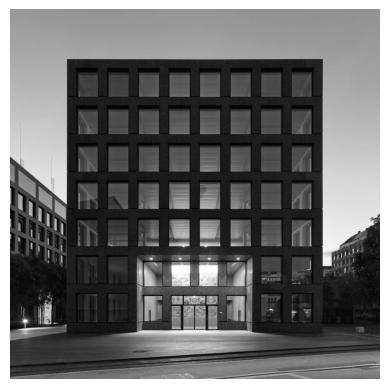

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("img1.jpg")

imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

plt.imshow(imagen_gris, cmap="gray")
plt.axis("off")

In [ ]:
def manual_convolution(image, kernel, stride, padding):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    n = kernel.shape[0]
    imagen_padded = np.pad(image, ((padding, padding), (padding, padding)), mode="constant", constant_values=0)

    alto_entrada, ancho_entrada = imagen_padded.shape
    alto_salida = (alto_entrada - n) // stride + 1
    ancho_salida = (ancho_entrada - n) // stride + 1

    if alto_salida <= 0 or ancho_salida <= 0:
        raise ValueError("Los hiperparámetros generan una salida inválida (revisa F, S, P).")

    salida = np.zeros((alto_salida, ancho_salida), dtype=float)

    for i in range(alto_salida):
        for j in range(ancho_salida):
            y = i * stride
            x = j * stride
            region = imagen_padded[y:y+n, x:x+n]
            salida[i, j] = np.sum(region * kernel)

    return salida

In [4]:
kernel_sobel_vertical = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

resultado = manual_convolution(
    image=imagen_gris,
    kernel=kernel_sobel_vertical,
    stride=1,
    padding=1
)

(-0.5, 1999.5, 1999.5, -0.5)

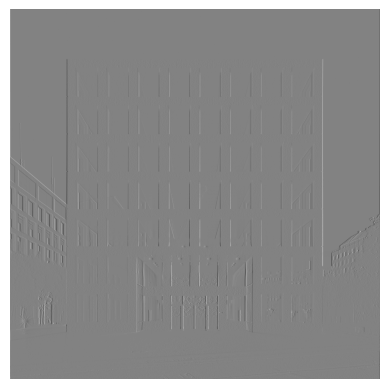

In [5]:
plt.imshow(resultado, cmap="gray")
plt.axis("off")

(-0.5, 399.5, 399.5, -0.5)

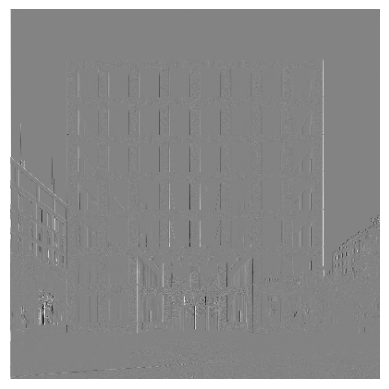

In [10]:
resultado1 = manual_convolution(
    image=imagen_gris,
    kernel=kernel_sobel_vertical,
    stride=5,
    padding=1
)

plt.imshow(resultado1, cmap="gray")
plt.axis("off")

El desplazamiento de Kernel se controla mediante el Stride, que determina cuántos píxeles se va a ir saltando el filtro durante la convolución. Cuando el Stride es igual a 1, el kerne se desplaza píxel por píxel, evaluando toda la región de la imagen. Esto produce un mapa de características más grande porque se realizan muchos más calculos. Cuando el Stride aumenta el kernel comienza a saltar píxeles lo que reduce la cantidad de veces que se realiza la convolución. Este cambio hace que la matriz de salida disminuya. Desde un punto computacional un Stride mayor reduce el número de operaciones y el consumo de memoria. Todo esto lo podemos ver en el ejemplo donde la matriz resultante es menor en el caso de Stride igual a 5 comparada con el Stride igual a 1 donde se mantiene el tamaño de la imagen. Además en el ejemplo se puede observar que la convoluación es exitosa ya que al aplicar un filtro sobel vertical se pueden distinguiar las zonas verticales. 